In [ ]:
import pandas as pd

In [4]:
df = pd.read_csv("priceprediction.csv")

In [5]:
df

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighbourhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East
...,...,...,...,...,...,...,...,...
123,124,119700,1900,3,3,3,Yes,East
124,125,147900,2160,4,3,3,Yes,East
125,126,113500,2070,2,2,2,No,North
126,127,149900,2020,3,3,1,No,West


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighbourhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [9]:
df.shape

(128, 8)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Home           128 non-null    int64
 1   Price          128 non-null    int64
 2   SqFt           128 non-null    int64
 3   Bedrooms       128 non-null    int64
 4   Bathrooms      128 non-null    int64
 5   Offers         128 non-null    int64
 6   Brick          128 non-null    str  
 7   Neighbourhood  128 non-null    str  
dtypes: int64(6), str(2)
memory usage: 8.1 KB


In [11]:
df.describe()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,2.578125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.069324
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,1.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,2.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,3.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,3.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,6.000000


In [13]:
df.columns

Index(['Home', 'Price', 'SqFt', 'Bedrooms', 'Bathrooms', 'Offers', 'Brick',
       'Neighbourhood'],
      dtype='str')

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.dtypes

Home             int64
Price            int64
SqFt             int64
Bedrooms         int64
Bathrooms        int64
Offers           int64
Brick              str
Neighbourhood      str
dtype: object

In [16]:
df.corr(numeric_only=True)

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
Home,1.000000,0.108190,0.168553,-0.068568,0.127694,-0.053597
Price,0.108190,1.000000,0.552982,0.525926,0.523258,-0.313636
SqFt,0.168553,0.552982,1.000000,0.483807,0.522745,0.336923
Bedrooms,-0.068568,0.525926,0.483807,1.000000,0.414556,0.114271
Bathrooms,0.127694,0.523258,0.522745,0.414556,1.000000,0.143793
Offers,-0.053597,-0.313636,0.336923,0.114271,0.143793,1.000000


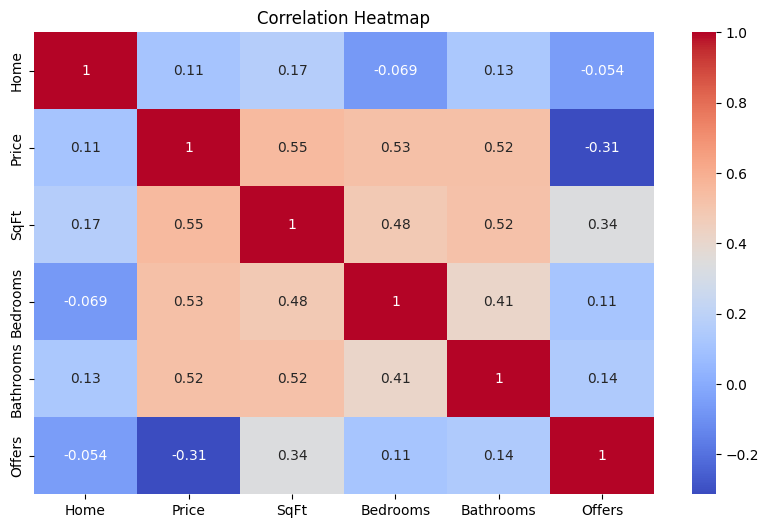

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

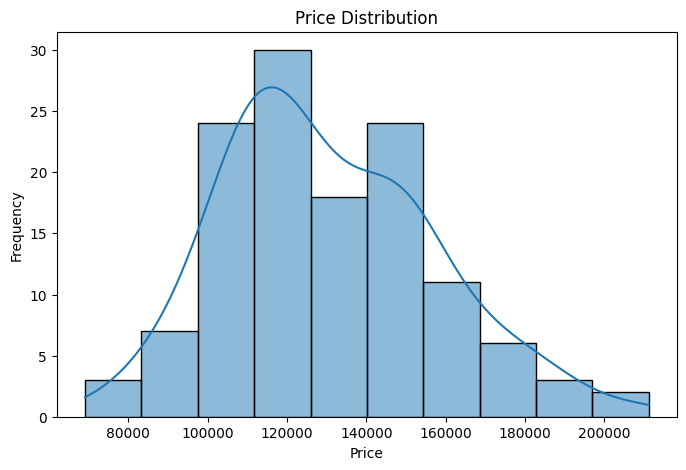

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

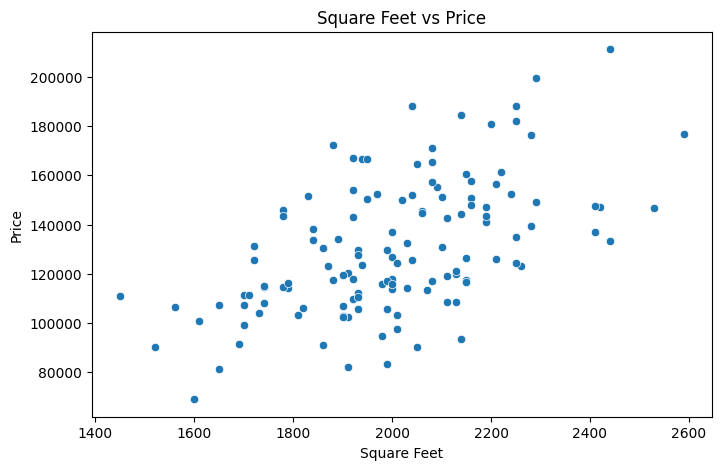

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["SqFt"], y=df["Price"])
plt.title("Square Feet vs Price")
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.show()

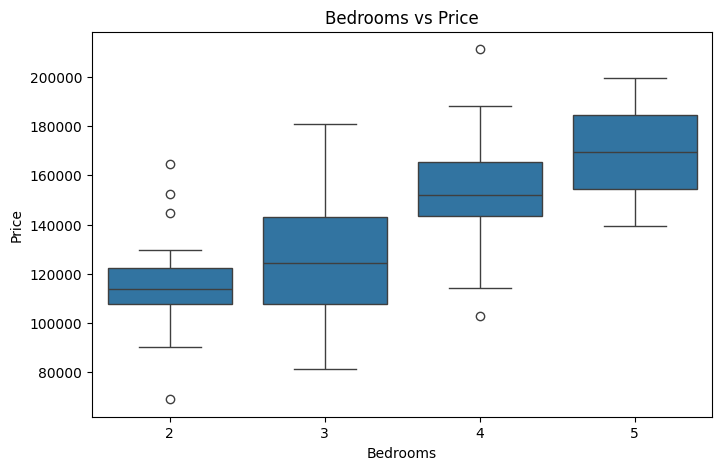

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Bedrooms"], y=df["Price"])
plt.title("Bedrooms vs Price")
plt.show()

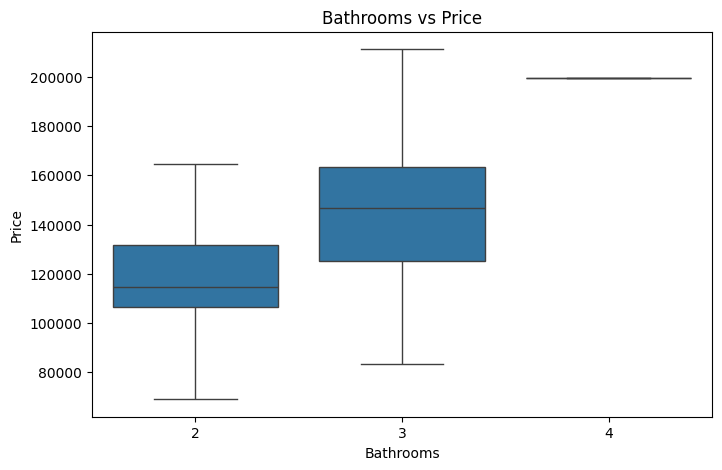

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Bathrooms"], y=df["Price"])
plt.title("Bathrooms vs Price")
plt.show()

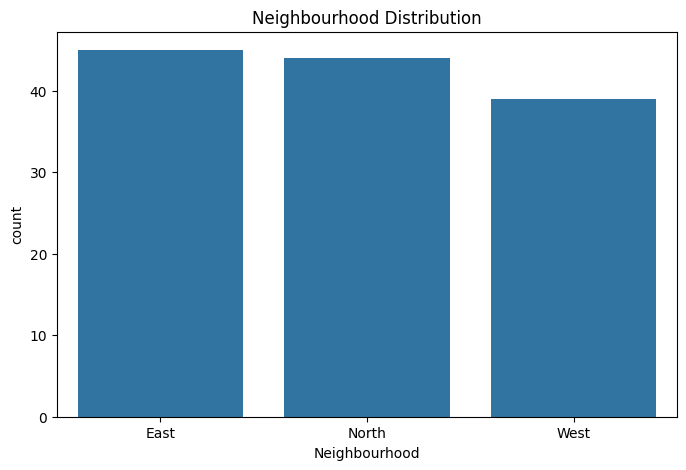

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["Neighbourhood"])
plt.title("Neighbourhood Distribution")
plt.show()

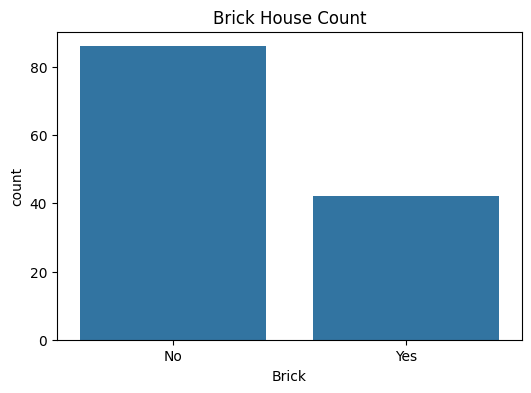

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Brick"])
plt.title("Brick House Count")
plt.show()

In [24]:
df.groupby("Neighbourhood")["Price"].mean()

Neighbourhood
East     125231.111111
North    110154.545455
West     159294.871795
Name: Price, dtype: float64

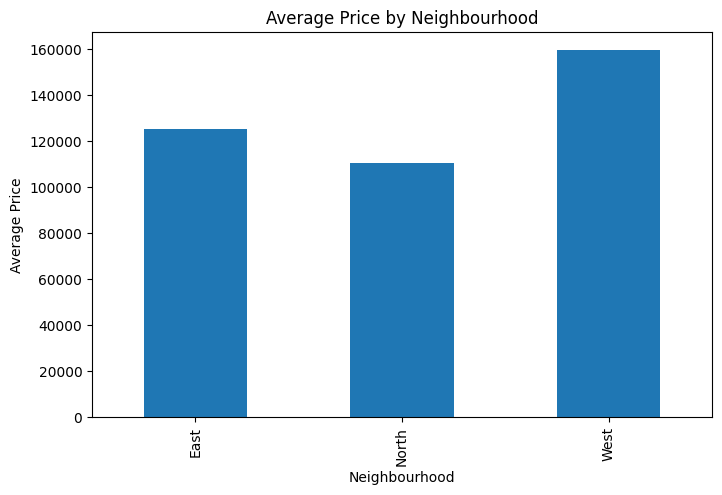

In [25]:
df.groupby("Neighbourhood")["Price"].mean().plot(kind="bar", figsize=(8,5))

plt.title("Average Price by Neighbourhood")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price")
plt.show()

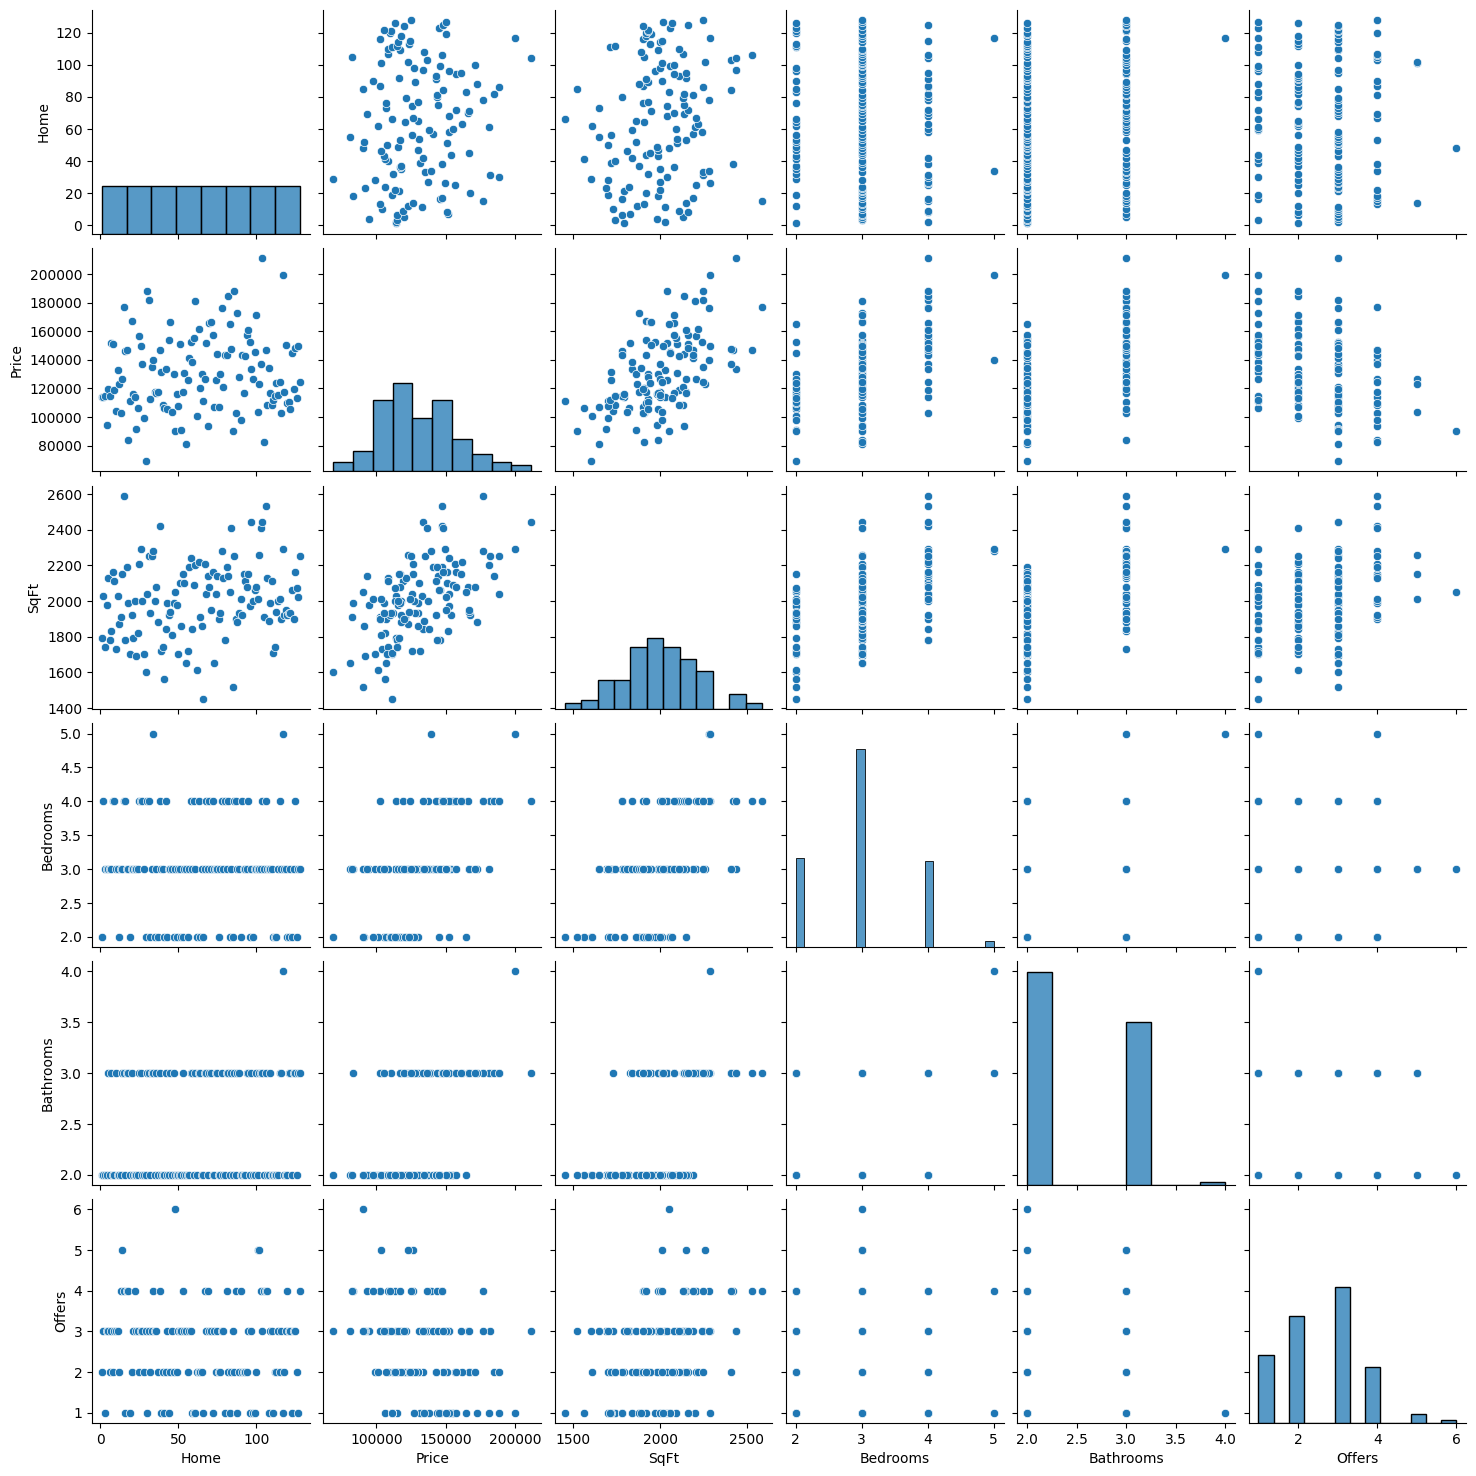

In [26]:
sns.pairplot(df)
plt.show()

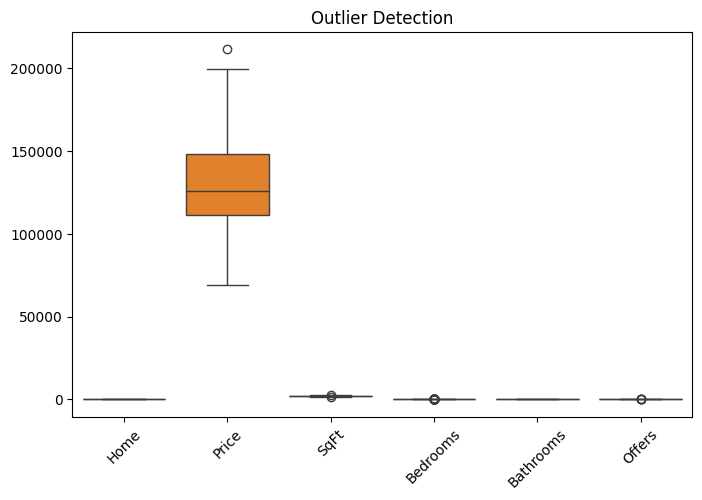

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

In [28]:
df["TotalRooms"] = df["Bedrooms"] + df["Bathrooms"]

In [29]:
df.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighbourhood,TotalRooms
0,1,114300,1790,2,2,2,No,East,4
1,2,114200,2030,4,2,3,No,East,6
2,3,114800,1740,3,2,1,No,East,5
3,4,94700,1980,3,2,3,No,East,5
4,5,119800,2130,3,3,3,No,East,6


In [30]:
df.to_csv("cleaned_house_data.csv", index=False)